<a href="https://colab.research.google.com/github/MarianaCastrillonM004/Analitica-de-Negocios/blob/main/Proyecto_Final_Walmart_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Proyecto Final: Predicción de Ventas (Walmart)**  


**Objetivo:** Estimar Weekly_Sales y analizar los principales impulsores de la demanda para soportar decisiones de inventarios, staffing y promociones.

**Variables:**
- Store: Store number
- Date: Sales week start date
- Weekly_Sales: Sales per week
- Holiday_Flag: Mark on the presence or absence of a holiday
- Temperature: Air temperature in the region
- Fuel_Price: Fuel cost in the region
- CPI: Consumer price index
- Unemployment: Unemployment rate

# **Librerias**

In [ ]:
# Importar las librerías necesarias para análisis de datos, manipulación de arrays, visualización y machine learning.
import numpy as np
import pandas as pd
from pathlib import Path # Para manejar rutas de archivos de manera más sencilla
import matplotlib.pyplot as plt # Para crear visualizaciones estáticas
from sklearn.pipeline import Pipeline # Para encadenar pasos de preprocesamiento y modelado
from sklearn.impute import SimpleImputer # Para imputar valores faltantes
from sklearn.compose import ColumnTransformer # Para aplicar diferentes transformaciones a diferentes columnas
from sklearn.model_selection import train_test_split # Para dividir los datos en conjuntos de entrenamiento y prueba
from sklearn.linear_model import LinearRegression, Ridge # Modelos de regresión lineal
from sklearn.preprocessing import OneHotEncoder, StandardScaler # Para codificación one-hot y escalado de características
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor # Modelos de ensamble para regresión
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error # Métricas para evaluar modelos de regresión

# Configurar pandas para mostrar todas las columnas de los DataFrames
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 120)

# **Carga de Datos + Preparación Inicial**

In [ ]:
# Definir la ruta del archivo de datos
DATA_PATH = Path('/content/Walmart_Sales.csv')
# Cargar el archivo CSV en un DataFrame de pandas
df = pd.read_csv(DATA_PATH)

# Iterar sobre las columnas para identificar y convertir las columnas de fecha a tipo datetime
for col in df.columns:
    if 'date' in col.lower():
        try:
            df[col] = pd.to_datetime(df[col])
        except Exception:
            # Si hay un error en la conversión, ignorar y dejar la columna como está
            pass

# Imprimir la forma del DataFrame (número de filas y columnas)
print("Shape:", df.shape)
# Imprimir los tipos de datos de cada columna
print("\nTipos de datos:")
print(df.dtypes)
# Imprimir el número de valores nulos por columna
print("\nNulos por columna:")
print(df.isna().sum())
# Mostrar las primeras 10 filas del DataFrame para una vista rápida
print("\nVista rápida:")
display(df.head(10))

Shape: (6435, 8)

Tipos de datos:
Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

Nulos por columna:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Vista rápida:


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
5,1,12-03-2010,1439541.59,0,57.79,2.667,211.380643,8.106
6,1,19-03-2010,1472515.79,0,54.58,2.720,211.215635,8.106
7,1,26-03-2010,1404429.92,0,51.45,2.732,211.018042,8.106
8,1,02-04-2010,1594968.28,0,62.27,2.719,210.820450,7.808
9,1,09-04-2010,1545418.53,0,65.86,2.770,210.622857,7.808


**Vizualizaciones Iniciales**

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Store,6435.0,NaN,NaN,NaN,23.0,12.988182,1.0,12.0,23.0,34.0,45.0
Date,6435,143,05-02-2010,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weekly_Sales,6435.0,NaN,NaN,NaN,1046964.877562,564366.622054,209986.25,553350.105,960746.04,1420158.66,3818686.45
Holiday_Flag,6435.0,NaN,NaN,NaN,0.06993,0.255049,0.0,0.0,0.0,0.0,1.0
Temperature,6435.0,NaN,NaN,NaN,60.663782,18.444933,-2.06,47.46,62.67,74.94,100.14
Fuel_Price,6435.0,NaN,NaN,NaN,3.358607,0.45902,2.472,2.933,3.445,3.735,4.468
CPI,6435.0,NaN,NaN,NaN,171.578394,39.356712,126.064,131.735,182.616521,212.743293,227.232807
Unemployment,6435.0,NaN,NaN,NaN,7.999151,1.875885,3.879,6.891,7.874,8.622,14.313


Objetivo: Weekly_Sales


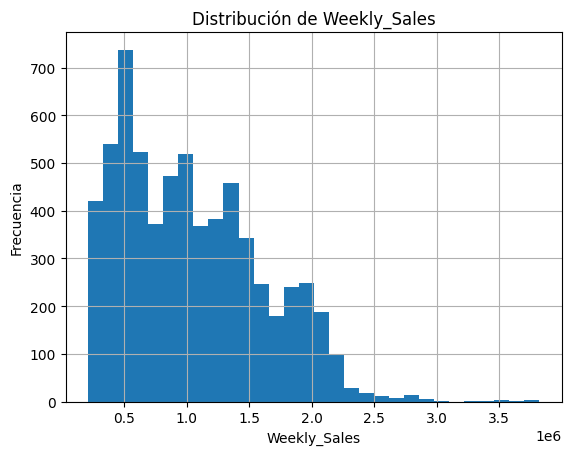

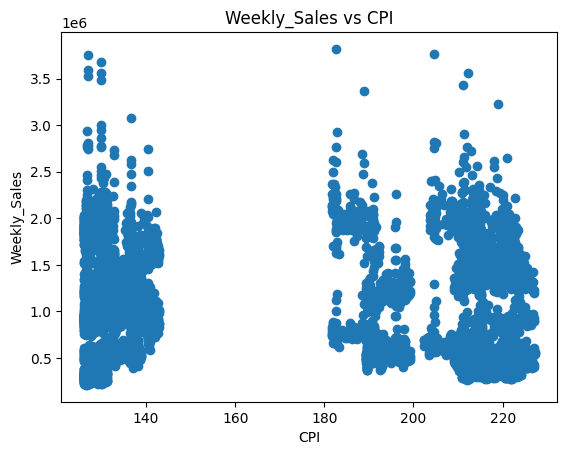

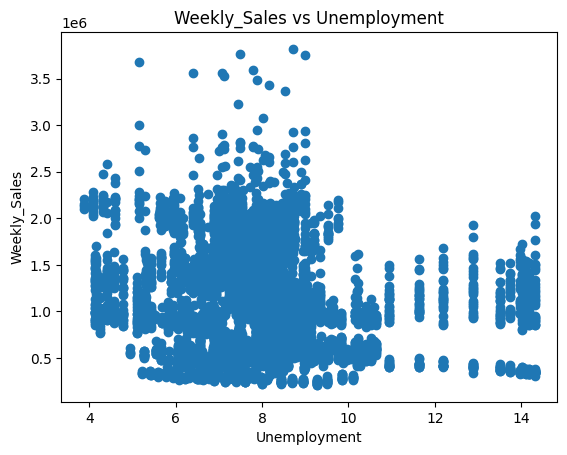

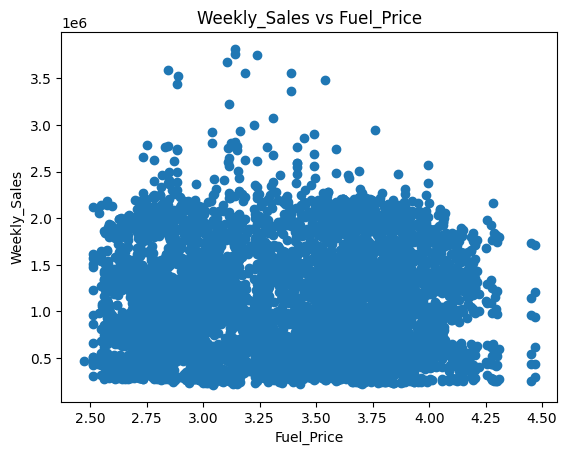

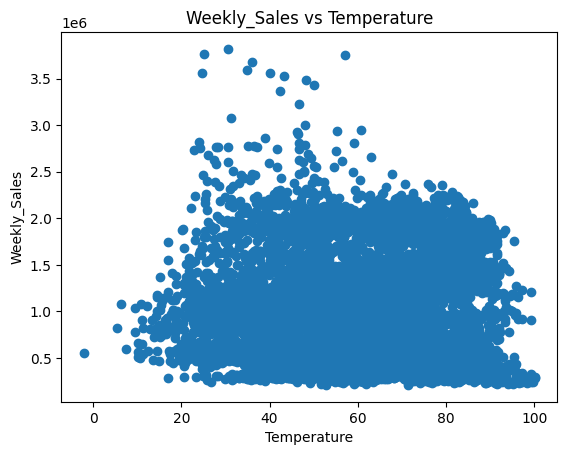

In [ ]:
# Calcular y mostrar estadísticas descriptivas del DataFrame, incluyendo columnas de tipo 'all' (numéricas y de objetos).
desc = df.describe(include='all').transpose() # Transponer la tabla para mejor visualización
display(desc) # Mostrar la tabla de estadísticas

# Seleccionar la variable objetivo. Busca 'Weekly_Sales' o cualquier columna que contenga 'sales'.
target_candidates = [c for c in df.columns if c.lower() == 'weekly_sales'] or \
                    [c for c in df.columns if 'sales' in c.lower()]
# Asegurarse de que se haya encontrado al menos una columna candidata para la variable objetivo.
assert len(target_candidates) > 0, "No se encontró la columna objetivo. Asegúrate de tener Weekly_Sales o similar."
# Asignar la primera columna candidata encontrada como la variable objetivo.
TARGET = target_candidates[0]
print("Objetivo:", TARGET) # Imprimir el nombre de la variable objetivo seleccionada.

# Generar histogramas y distribuciones utilizando matplotlib.
# NOTA: No se especifican colores, se utilizan los valores predeterminados de matplotlib.

# Histograma de la variable objetivo (Weekly_Sales)
plt.figure() # Crear una nueva figura para el gráfico.
df[TARGET].dropna().hist(bins=30) # Generar el histograma, ignorando valores nulos y usando 30 bins.
plt.title("Distribución de Weekly_Sales") # Establecer el título del gráfico.
plt.xlabel("Weekly_Sales") # Establecer la etiqueta del eje x.
plt.ylabel("Frecuencia") # Establecer la etiqueta del eje y.
plt.show() # Mostrar el gráfico.

# Si existe una columna de fecha (tipo datetime), generar gráfico de ventas promedio por semana del año.
date_cols = [c for c in df.columns if 'date' in c.lower() and np.issubdtype(df[c].dtype, np.datetime64)]
if date_cols: # Verificar si se encontraron columnas de fecha.
    dcol = date_cols[0] # Seleccionar la primera columna de fecha encontrada.
    tmp = df[[dcol, TARGET]].copy() # Crear una copia temporal con la columna de fecha y la variable objetivo.
    tmp['weekofyear'] = tmp[dcol].dt.isocalendar().week.astype(int) # Extraer la semana del año y convertir a entero.
    # Agrupar por semana del año y calcular el promedio de Weekly_Sales.
    avg_week = tmp.groupby('weekofyear')[TARGET].mean().reset_index()

    plt.figure() # Crear una nueva figura para el gráfico.
    plt.plot(avg_week['weekofyear'], avg_week[TARGET]) # Crear el gráfico de línea.
    plt.title("Weekly_Sales promedio por semana del año") # Establecer el título del gráfico.
    plt.xlabel("Semana del año") # Establecer la etiqueta del eje x.
    plt.ylabel("Weekly_Sales promedio") # Establecer la etiqueta del eje y.
    plt.show() # Mostrar el gráfico.

# Generar gráficos de dispersión para mostrar la relación entre la variable objetivo y variables numéricas típicas.
num_candidates = ['CPI','Unemployment','Fuel_Price','Temperature'] # Lista de nombres de columnas numéricas a considerar.
for nc in num_candidates: # Iterar sobre cada nombre de columna numérica.
    if nc in df.columns: # Verificar si la columna existe en el DataFrame.
        plt.figure() # Crear una nueva figura para el gráfico.
        plt.scatter(df[nc], df[TARGET]) # Crear el gráfico de dispersión.
        plt.title(f"{TARGET} vs {nc}") # Establecer el título del gráfico con los nombres de las variables.
        plt.xlabel(nc) # Establecer la etiqueta del eje x.
        plt.ylabel(TARGET) # Establecer la etiqueta del eje y.
        plt.show() # Mostrar el gráfico.

**Organización Variables**

In [ ]:
# Definimos X, y
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Detección de tipos
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category','bool']).columns.tolist()

print("Variables numéricas:", num_cols)
print("Variables categóricas:", cat_cols)

Variables numéricas: ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
Variables categóricas: ['Date']


In [ ]:
# Identificar columnas de fecha en el DataFrame que sean de tipo datetime.
date_cols = [c for c in df.columns if 'date' in c.lower() and np.issubdtype(df[c].dtype, np.datetime64)]

# Si se encuentran columnas de fecha:
if date_cols:
    dcol = date_cols[0] # Seleccionar la primera columna de fecha.
    # Extraer componentes de la fecha y crear nuevas columnas en el DataFrame.
    df['year'] = df[dcol].dt.year # Año
    df['month'] = df[dcol].dt.month # Mes
    df['weekofyear'] = df[dcol].dt.isocalendar().week.astype(int) # Semana del año (ISO 8601), convertir a entero
    df['quarter'] = df[dcol].dt.quarter # Trimestre
    df['is_month_end'] = df[dcol].dt.is_month_end.astype(int) # Indicador de fin de mes (1 si es fin de mes, 0 si no), convertir a entero
    # Eliminar la columna de fecha original para evitar problemas en el preprocesamiento posterior.
    df = df.drop(columns=[dcol])

# Definir las variables predictoras (X) y la variable objetivo (y).
# X es el DataFrame sin la columna objetivo.
X = df.drop(columns=[TARGET])
# y es la Serie con la columna objetivo.
y = df[TARGET]

# Detectar los tipos de columnas después de la ingeniería de variables.
# num_cols son las columnas con tipos numéricos.
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
# cat_cols son las columnas con tipos de objeto, categoría o booleano.
cat_cols = X.select_dtypes(include=['object','category','bool']).columns.tolist()

# Imprimir las listas de columnas numéricas y categóricas.
print("Variables numéricas:", num_cols)
print("Variables categóricas:", cat_cols)

Variables numéricas: ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
Variables categóricas: ['Date']


# **Split Train/Test**

In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba.
# X_train, y_train para entrenar el modelo.
# X_test, y_test para evaluar el modelo.
# test_size=0.2 indica que el 20% de los datos se usarán para prueba.
# random_state=42 asegura que la división sea la misma cada vez que se ejecute.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear un pipeline para transformar las columnas numéricas.
# 1. Imputar valores faltantes con la mediana.
# 2. Escalar las características numéricas (sin centrar, solo escalar por desviación estándar).
numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler(with_mean=False))])

# Crear un pipeline para transformar las columnas categóricas.
# 1. Imputar valores faltantes con la moda (valor más frecuente).
# 2. Aplicar codificación One-Hot (crear columnas binarias para cada categoría).
#    handle_unknown='ignore' maneja categorías desconocidas en el conjunto de prueba.
categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Combinar los transformadores en un ColumnTransformer.
# Aplica el 'numeric_transformer' a las 'num_cols'.
# Aplica el 'categorical_transformer' a las 'cat_cols'.
# 'remainder='drop'' descarta las columnas que no se especifican en 'transformers'.
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, num_cols),('cat', categorical_transformer, cat_cols)],remainder='drop')

# **Modelos**

In [ ]:
# Definir un diccionario con los modelos de regresión a entrenar.
# Cada clave es el nombre del modelo y el valor es la instancia del modelo.
modelos = {'LinearRegression': LinearRegression(),
           'Ridge': Ridge(alpha=1.0), # Ridge con un parámetro de regularización alpha de 1.0
           'RandomForest': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1), # RandomForest con 300 árboles, estado aleatorio fijo y usando todos los núcleos disponibles
           'GradientBoosting': GradientBoostingRegressor(random_state=42)} # GradientBoosting con estado aleatorio fijo

# Función para calcular métricas de evaluación del modelo.
# y_true son los valores reales, y_pred son las predicciones del modelo.
def calcular_metricas(y_true, y_pred):
    r2 = r2_score(y_true, y_pred) # Calcular el coeficiente de determinación (R^2)
    mae = mean_absolute_error(y_true, y_pred) # Calcular el Error Absoluto Medio (MAE)
    # Calcular el Error Cuadrático Medio (MSE) y luego la Raíz del Error Cuadrático Medio (RMSE).
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, mae, rmse # Devolver las métricas

# Inicializar listas y diccionarios para almacenar resultados y modelos entrenados.
resultados = [] # Lista para almacenar los resultados de evaluación de cada modelo.
modelos_entrenados = {} # Diccionario para almacenar los pipelines entrenados.

# Iterar sobre cada modelo definido en el diccionario 'modelos'.
for nombre, modelo in modelos.items():
    # Crear un pipeline que primero aplica el preprocesamiento y luego el modelo.
    pipe = Pipeline(steps=[('prep', preprocessor), ('model', modelo)])
    # Entrenar el pipeline (preprocesamiento y modelo) con los datos de entrenamiento.
    pipe.fit(X_train, y_train)
    # Realizar predicciones en el conjunto de prueba.
    y_pred = pipe.predict(X_test)
    # Calcular las métricas de evaluación para las predicciones.
    r2, mae, rmse = calcular_metricas(y_test, y_pred)
    # Agregar los resultados a la lista de resultados.
    resultados.append({'Modelo': nombre, 'R2': r2, 'MAE': mae, 'RMSE': rmse})
    # Almacenar el pipeline entrenado en el diccionario 'modelos_entrenados'.
    modelos_entrenados[nombre] = pipe

**Mejor Modelo**

,Modelo,R2,MAE,RMSE
0,Ridge,0.156465,434722.026183,521295.150026
1,LinearRegression,0.156524,434691.305820,521276.963648
2,GradientBoosting,0.870652,152488.092962,204132.805227
3,RandomForest,0.937702,73586.564911,141667.565493


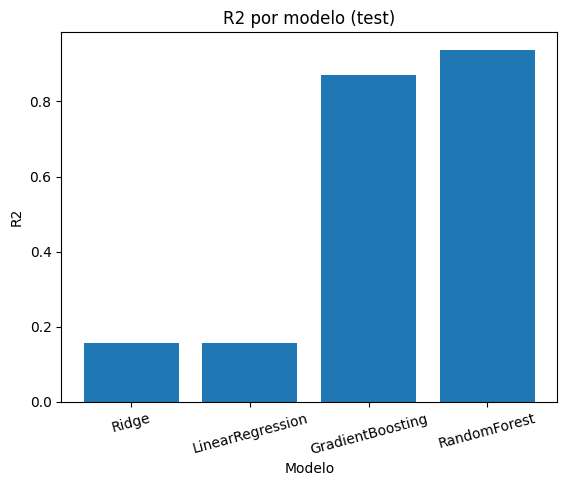

In [ ]:
# Convertir la lista de resultados en un DataFrame y ordenarlo por 2.
resultados_df = pd.DataFrame(resultados).sort_values('R2').reset_index(drop=True)
# Mostrar el DataFrame de resultados.
display(resultados_df)

# Generar un gráfico de barras simple para visualizar el RMSE de cada modelo.
plt.figure() # Crear una nueva figura para el gráfico.
plt.bar(resultados_df['Modelo'], resultados_df['R2']) # Crear el gráfico de barras.
plt.title("R2 por modelo (test)") # Establecer el título del gráfico.
plt.xlabel("Modelo") # Establecer la etiqueta del eje x.
plt.ylabel("R2") # Establecer la etiqueta del eje y.
plt.xticks(rotation=15) # Rotar las etiquetas del eje x para mejor legibilidad.
plt.show() # Mostrar el gráfico.

**Train vs Test**

Agregar una celda de código en la sección "Diagnostico Mejor Modelo" para calcular y mostrar las métricas (R2, MAE, RMSE) para los conjuntos de entrenamiento y prueba para cada modelo entrenado.

In [ ]:
train_test_metrics = []

for name, pipe in modelos_entrenados.items():
    # Predictions on training set
    y_train_pred = pipe.predict(X_train)
    r2_train, mae_train, rmse_train = calcular_metricas(y_train, y_train_pred)

    # Predictions on test set
    y_test_pred = pipe.predict(X_test)
    r2_test, mae_test, rmse_test = calcular_metricas(y_test, y_test_pred)

    train_test_metrics.append({'Modelo': name, 'Set': 'Train', 'R2': r2_train, 'MAE': mae_train, 'RMSE': rmse_train})
    train_test_metrics.append({'Modelo': name, 'Set': 'Test', 'R2': r2_test, 'MAE': mae_test, 'RMSE': rmse_test})

train_test_metrics_df = pd.DataFrame(train_test_metrics)
display(train_test_metrics_df)

,Modelo,Set,R2,MAE,RMSE
0,LinearRegression,Train,0.189838,421546.907007,507188.631171
1,LinearRegression,Test,0.156524,434691.305820,521276.963648
2,Ridge,Train,0.189613,421555.819922,507259.106431
3,Ridge,Test,0.156465,434722.026183,521295.150026
4,RandomForest,Train,0.992191,25794.077963,49793.191616
5,RandomForest,Test,0.937702,73586.564911,141667.565493
6,GradientBoosting,Train,0.884608,146868.728256,191412.969984
7,GradientBoosting,Test,0.870652,152488.092962,204132.805227


**Sobreajuste**

Analizar los resultados de la comparación entre train y test para identificar sobreajuste significativo. Si se identifica sobreajuste, corregirlo aplicando técnicas de regularización o ajustando hiperparámetros en los modelos afectados (RandomForest en este caso).


In [ ]:
# Examine train_test_metrics_df
print("\nTrain vs Test Metrics:")
display(train_test_metrics_df)

# Check for overfitting, specifically for RandomForest
rf_metrics = train_test_metrics_df[train_test_metrics_df['Modelo'] == 'RandomForest']
r2_train_rf = rf_metrics[rf_metrics['Set'] == 'Train']['R2'].iloc[0]
r2_test_rf = rf_metrics[rf_metrics['Set'] == 'Test']['R2'].iloc[0]
mae_train_rf = rf_metrics[rf_metrics['Set'] == 'Train']['MAE'].iloc[0]
mae_test_rf = rf_metrics[rf_metrics['Set'] == 'Test']['MAE'].iloc[0]

print(f"\nRandomForest R2 Train: {r2_train_rf:.4f}, R2 Test: {r2_test_rf:.4f}")
print(f"RandomForest MAE Train: {mae_train_rf:.2f}, MAE Test: {mae_test_rf:.2f}")

# If there's a significant drop in R2 or increase in MAE, indicative of overfitting, adjust hyperparameters
# A large difference between train and test R2 (e.g., > 0.1) or MAE suggests overfitting.
overfitting_threshold_r2 = 0.05 # Threshold for R2 difference
overfitting_threshold_mae = 50000 # Threshold for MAE difference

significant_overfitting = (r2_train_rf - r2_test_rf > overfitting_threshold_r2) or \
                          (mae_test_rf - mae_train_rf > overfitting_threshold_mae)

if significant_overfitting:
    print("\nSignificant overfitting detected in RandomForest. Adjusting hyperparameters.")
    # Adjust hyperparameters to reduce complexity (example: max_depth, min_samples_leaf)
    # Note: These are example values, tuning might be needed.
    modelos['RandomForest'] = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1, max_depth=10, min_samples_leaf=5)

    # Re-train the affected model (RandomForest) and re-evaluate
    pipe_rf = Pipeline(steps=[('prep', preprocessor), ('model', modelos['RandomForest'])])
    pipe_rf.fit(X_train, y_train)
    y_pred_train_rf_new = pipe_rf.predict(X_train)
    y_pred_test_rf_new = pipe_rf.predict(X_test)

    r2_train_rf_new, mae_train_rf_new, rmse_train_rf_new = calcular_metricas(y_train, y_pred_train_rf_new)
    r2_test_rf_new, mae_test_rf_new, rmse_test_rf_new = calcular_metricas(y_test, y_pred_test_rf_new)

    print(f"\nRandomForest (Adjusted) R2 Train: {r2_train_rf_new:.4f}, R2 Test: {r2_test_rf_new:.4f}")
    print(f"RandomForest (Adjusted) MAE Train: {mae_train_rf_new:.2f}, MAE Test: {mae_test_rf_new:.2f}")

    # Update models_entrenados and results_df with the new RandomForest model metrics
    modelos_entrenados['RandomForest'] = pipe_rf

    # Find and update or add the new RandomForest metrics in train_test_metrics_df
    train_test_metrics_df = train_test_metrics_df[train_test_metrics_df['Modelo'] != 'RandomForest'].copy()

    train_test_metrics_df = pd.concat([train_test_metrics_df, pd.DataFrame([{
        'Modelo': 'RandomForest', 'Set': 'Train', 'R2': r2_train_rf_new, 'MAE': mae_train_rf_new, 'RMSE': rmse_train_rf_new}, {'Modelo': 'RandomForest', 'Set': 'Test', 'R2': r2_test_rf_new, 'MAE': mae_test_rf_new, 'RMSE': rmse_test_rf_new}])], ignore_index=True)

    # Re-generate results_df from the updated train_test_metrics_df (only test set for simplicity)
    resultados_df = train_test_metrics_df[train_test_metrics_df['Set'] == 'Test'].sort_values('R2', ascending=False).reset_index(drop=True)

    print("\nUpdated Train vs Test Metrics:")
    display(train_test_metrics_df)
    print("\nUpdated Test Metrics (resultados_df):")
    display(resultados_df)

else:
    print("\nSignificant overfitting not detected in RandomForest based on the defined thresholds.")

# Re-run the diagnosis and importance steps if needed


Train vs Test Metrics:


,Modelo,Set,R2,MAE,RMSE
0,LinearRegression,Train,0.189838,421546.907007,507188.631171
1,LinearRegression,Test,0.156524,434691.305820,521276.963648
2,Ridge,Train,0.189613,421555.819922,507259.106431
3,Ridge,Test,0.156465,434722.026183,521295.150026
4,RandomForest,Train,0.992191,25794.077963,49793.191616
5,RandomForest,Test,0.937702,73586.564911,141667.565493
6,GradientBoosting,Train,0.884608,146868.728256,191412.969984
7,GradientBoosting,Test,0.870652,152488.092962,204132.805227



RandomForest R2 Train: 0.9922, R2 Test: 0.9377
RandomForest MAE Train: 25794.08, MAE Test: 73586.56

Significant overfitting detected in RandomForest. Adjusting hyperparameters.

RandomForest (Adjusted) R2 Train: 0.9488, R2 Test: 0.9284
RandomForest (Adjusted) MAE Train: 68230.51, MAE Test: 80434.09

Updated Train vs Test Metrics:


,Modelo,Set,R2,MAE,RMSE
0,LinearRegression,Train,0.189838,421546.907007,507188.631171
1,LinearRegression,Test,0.156524,434691.305820,521276.963648
2,Ridge,Train,0.189613,421555.819922,507259.106431
3,Ridge,Test,0.156465,434722.026183,521295.150026
4,GradientBoosting,Train,0.884608,146868.728256,191412.969984
5,GradientBoosting,Test,0.870652,152488.092962,204132.805227
6,RandomForest,Train,0.948825,68230.513417,127471.496191
7,RandomForest,Test,0.928365,80434.089943,151913.406583



Updated Test Metrics (resultados_df):


,Modelo,Set,R2,MAE,RMSE
0,RandomForest,Test,0.928365,80434.089943,151913.406583
1,GradientBoosting,Test,0.870652,152488.092962,204132.805227
2,LinearRegression,Test,0.156524,434691.305820,521276.963648
3,Ridge,Test,0.156465,434722.026183,521295.150026


# **Desempeño + Importancia Variables**

Best model after potential adjustment: RandomForest


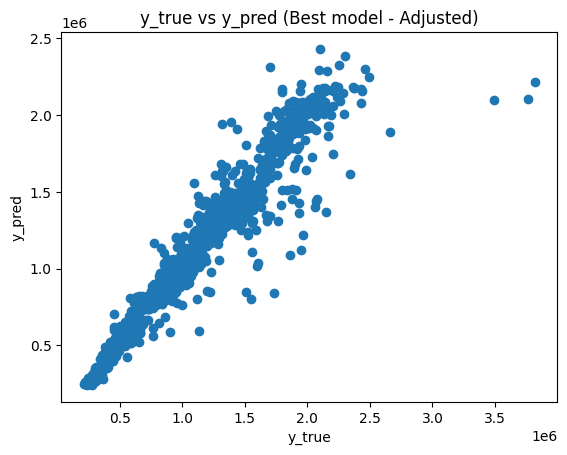

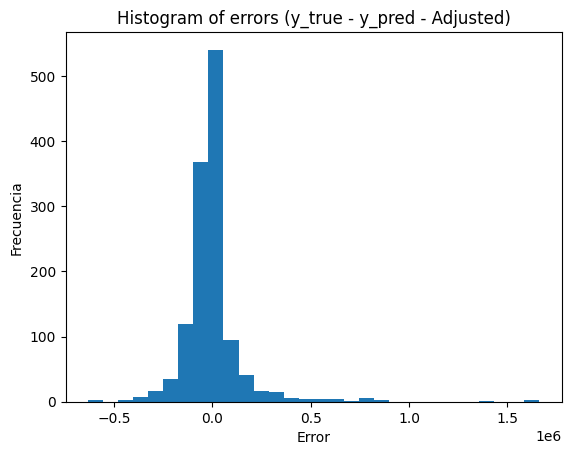


Updated Feature Importances for RandomForest:


/tmp/ipython-input-1431859144.py:42: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  importancias_df = pd.concat([importancias_df, tmp], ignore_index=True)


,feature,importance,Modelo
0,Store,0.705197,RandomForest
1,CPI,0.160642,RandomForest
2,Unemployment,0.106021,RandomForest
3,Temperature,0.014907,RandomForest
4,Fuel_Price,0.011557,RandomForest
5,Holiday_Flag,0.000918,RandomForest
6,Date_24-12-2010,0.000686,RandomForest
7,Date_23-12-2011,0.000072,RandomForest
8,Date_01-04-2011,0.000000,RandomForest
9,Date_01-10-2010,0.000000,RandomForest


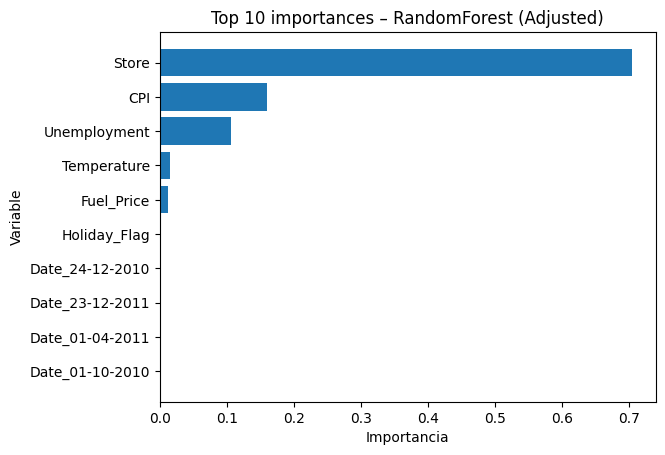

In [ ]:
# Re-generate diagnostic plots for the best model (RandomForest, potentially adjusted)
best_name = resultados_df.iloc[0]['Modelo']
best_pipe = modelos_entrenados[best_name]
y_pred_best = best_pipe.predict(X_test)

print("Best model after potential adjustment:", best_name)

plt.figure()
plt.scatter(y_test, y_pred_best)
plt.title("y_true vs y_pred (Best model - Adjusted)")
plt.xlabel("y_true")
plt.ylabel("y_pred")
plt.show()

errores = y_test - y_pred_best
plt.figure()
plt.hist(errores, bins=30)
plt.title("Histogram of errors (y_true - y_pred - Adjusted)")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()

# Re-generate feature importance for the adjusted RandomForest model
importancias_df = pd.DataFrame(columns=['feature','importance','Modelo'])

tree_name = 'RandomForest' # Only re-evaluate RandomForest
if tree_name in modelos_entrenados:
    pipe = modelos_entrenados[tree_name]
    model = pipe.named_steps['model']
    ct = pipe.named_steps['prep']
    try:
        feature_names = get_feature_names(ct)
    except Exception:
        n_feats = ct.transform(X_train.iloc[:1]).shape[1]
        feature_names = np.array([f'feat_{i}' for i in range(n_feats)])

    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
        tmp = pd.DataFrame({'feature': feature_names, 'importance': imp})
        tmp = tmp.sort_values('importance', ascending=False).head(25).reset_index(drop=True)
        tmp['Modelo'] = tree_name
        importancias_df = pd.concat([importancias_df, tmp], ignore_index=True)

print("\nUpdated Feature Importances for RandomForest:")
display(importancias_df.head(15))

if len(importancias_df) > 0:
    rf_top10 = importancias_df[importancias_df['Modelo']==tree_name].head(10)
    if len(rf_top10) > 0:
        plt.figure()
        plt.barh(rf_top10['feature'][::-1], rf_top10['importance'][::-1])
        plt.title(f"Top 10 importances – {tree_name} (Adjusted)")
        plt.xlabel("Importancia")
        plt.ylabel("Variable")
        plt.show()

# **Informe Ejecutivo**

Los resultados del análisis apuntan a varias conclusiones estratégicas clave que Walmart debería tener en cuenta para mejorar el rendimiento de las ventas y la precisión de las previsiones.

**1.	Alta Variabilidad en Tiendas:** El modelo asignó una importancia de 0,70 a la variable «Tienda», lo que significa que la mayor parte de la variación en las ventas se explica simplemente por la tienda de la que proceden los datos. → Esto indica que el rendimiento de las ventas es muy desigual entre las tiendas. El modelo reveló que el reto más importante en el conjunto de datos de Walmart es la alta variabilidad entre tiendas, lo que indica que algunas tiendas tienen un rendimiento excepcionalmente bueno, mientras que otras tienen un rendimiento consistentemente inferior. Esta distribución desigual de las ventas sugiere que los factores que impulsan el rendimiento no son uniformes en todas las ubicaciones y que faltan datos contextuales adicionales en el conjunto de datos. El primer subproblema surge de las grandes diferencias en las ventas de las tiendas que el modelo no puede explicar utilizando otras variables disponibles. Si bien características como el IPC, el desempleo y la temperatura proporcionan cierto poder explicativo, no captan los factores locales que realmente impulsan las ventas de cada tienda. Esto significa que dos tiendas que operan en condiciones macroeconómicas similares pueden mostrar resultados completamente diferentes, lo que implica que otras dinámicas locales, como la demografía, la accesibilidad, las prácticas de gestión o incluso la distribución de la tienda, desempeñan un papel influyente.
Para abordar esta cuestión, Walmart debería analizar por separado las tiendas con mejor y peor rendimiento para comprender qué impulsa estas disparidades. Al identificar los elementos diferenciadores, ya sea la eficiencia operativa, la base de clientes o las características regionales, Walmart puede diseñar estrategias de mejora específicas para las ubicaciones más débiles.

El segundo subproblema es que la variable «Tienda» domina el modelo, con una puntuación de importancia de 0,70, lo que revela que explica la variación inexplicada relacionada con las condiciones específicas de cada tienda. Básicamente, el modelo está aprendiendo que «de qué tienda» proceden los datos explica la mayor parte de la variación, pero no puede especificar por qué. Este dominio indica que faltan variables explicativas relacionadas con los atributos de la tienda, como el tamaño de la tienda, los ingresos regionales o la densidad de la competencia local. Para resolver esto, Walmart debería ampliar su recopilación de datos para incluir más indicadores geográficos y a nivel de tienda. Añadir información adicional hará que el modelo sea más interpretable y permitirá a Walmart actuar sobre los factores exactos en lugar de basarse en la identidad de la tienda como predictor generalizado. Enriquecer el conjunto de datos con métricas significativas a nivel de tienda transformaría las predicciones de Random Forest en información útil en lugar de correlaciones vinculadas a los códigos de las tiendas.
Por último, el histograma de ventas semanales revela una distribución que solo está ligeramente sesgada hacia la derecha, en lugar de estar dominada por valores atípicos. La mayoría de las observaciones de ventas se sitúan entre 400.000 y 1.500.000, con una disminución gradual de la frecuencia a medida que aumentan las ventas. Esto indica que, aunque hay algunas semanas o tiendas con un rendimiento muy alto, la mayoría de los establecimientos de Walmart mantienen un rendimiento semanal medio y relativamente estable. En términos de negocio, esto significa que la red de ventas de Walmart no depende excesivamente de un pequeño número de tiendas líderes, sino que muestra una variación moderada en toda la red. La distribución sugiere que existen diferencias de rendimiento, pero no son extremas. Por lo tanto, en lugar de centrarse únicamente en los valores atípicos, Walmart debería identificar y comprender qué diferencia a las tiendas de rendimiento medio de las de primer nivel, y utilizar esta información para elevar el nivel de rendimiento general en todas sus ubicaciones.

En conjunto, los resultados del modelo y el histograma se complementan entre sí, ofreciendo una visión más completa de la dinámica del rendimiento de Walmart. Mientras que el histograma muestra que la variación de las ventas entre las tiendas es moderada, y que la mayoría de los establecimientos se sitúan en un rango medio estable, el modelo revela que estas diferencias son sistemáticas y no aleatorias. En otras palabras, las variaciones constantes que se observan en el histograma se explican en gran medida por la identidad de la tienda, lo que significa que cada tienda tiene su propio nivel de ventas característico, influido por factores que no se recogen en el conjunto de datos. Esta información refuerza la idea de que las diferencias de rendimiento de Walmart no son el resultado de excepciones aisladas o valores atípicos extremos, sino más bien de condiciones específicas de cada tienda que determinan los resultados a largo plazo.
En conclusión, comprender esto pone de relieve la importancia de recopilar información a nivel de tienda y desarrollar estrategias personalizadas que aborden las causas fundamentales de estas diferencias estructurales, en lugar de tratarlas como fluctuaciones aleatorias.


**2. Moderada Dependencia en Condiciones Macroeconómicas:** El CPI (Índice de Precios al Consumidor) y el desempleo explican juntos alrededor del 25 % de la importancia de la decisión del modelo. → Esto significa que las ventas de Walmart son moderadamente sensibles a la inflación y a las condiciones del mercado laboral, lo que confirma que los cambios en la estabilidad económica afectan al comportamiento de los consumidores.

Este hallazgo indica que el rendimiento de las ventas de Walmart es ligeramente sensible a los cambios en los niveles de inflación y empleo, lo que sugiere que los cambios en la estabilidad económica influyen directamente en el comportamiento de compra de los consumidores. Es probable que una mayor inflación reduzca los ingresos disponibles de los consumidores, lo que conduce a un gasto más restringido y a menores ventas, mientras que un menor desempleo tiende a impulsar el poder adquisitivo y el tráfico en las tiendas. Sin embargo, la importancia relativamente moderada de estas variables también implica que, si bien los factores macroeconómicos son importantes, no dictan por completo el rendimiento, ya que los factores locales y específicos de cada tienda siguen desempeñando un papel más importante. En la práctica, esto significa que Walmart debe seguir vigilando estos indicadores económicos para anticiparse a las fluctuaciones de la demanda, pero también reforzar su capacidad para adaptar las estrategias de precios, promociones e inventario a nivel regional. Esto ayudaría a la empresa a mantener un rendimiento de ventas estable incluso en presencia de una mayor volatilidad económica.


**3. Inflencia Débil de Short-Term or Seasonal Factors:** Las variables Temperature, Fuel_Price y Holiday_Flag tienen una importancia muy baja en el modelo (todas por debajo del 1%), lo que sugiere que no influyen significativamente en las variaciones semanales de ventas.
Esto significa que, en el periodo analizado, factores como el clima, los precios del combustible o los feriados no fueron determinantes. Es posible que su efecto sea inconsistente o esté opacado por factores estructurales como la ubicación de las tiendas o la estabilidad económica.

Estas solo influyen de manera secundaria en los cambios en las ventas semanales de Walmart, lo que sugiere que estas variables ambientales a corto plazo tienen una influencia limitada en el rendimiento general. Ambas variables obtuvieron puntuaciones muy bajas en cuanto a la importancia de sus características, lo que significa que contribuyen poco a la capacidad del modelo para predecir las ventas en comparación con los factores específicos de la tienda o los factores macroeconómicos. Este patrón indica que, no son lo suficientemente constantes o importantes como para alterar de manera significativa las ventas totales. Por ejemplo, los clientes pueden retrasar ciertas compras no esenciales durante semanas inusualmente calientes o frías, o reducir los desplazamientos cuando suben los precios del combustible, pero estas fluctuaciones no son duraderas. Por lo tanto, los datos sugieren que la base de clientes de Walmart se mantiene relativamente estable y no se ve afectada por estos factores, probablemente debido al sólido posicionamiento de la empresa en productos esenciales y a la amplia accesibilidad de sus tiendas. Desde una perspectiva empresarial, Walmart debería seguir reconociendo estos factores como influencias secundarias que pueden ayudar a ajustar la planificación operativa, en lugar de como predictores claves de la demanda. Los ajustes estacionales de inventario, la publicidad local dirigida durante condiciones climáticas extremas o las campañas de accesibilidad local durante períodos de altos precios del combustible podrían utilizarse tácticamente para mantener unas ventas estables incluso cuando se producen influencias externas menores.
